# Adjoints and Backprop, Part 2: What is backpropagation?

*Part 1 introduced adjoint methods. This part is a short, self-contained look at backpropagation, the algorithm used to train neural networks. Part 3 puts the two side by side.*

If you've trained a neural network, you've used backpropagation, though probably through a library that hid it from you. Below we'll write it out by hand for a small network, check that it's right, and then use it to fit a curve. The goal here is to assemble the equations of backprop in a form we can compare with Part 1.

**In this part:**

1. A neural network is a loop
2. Backpropagation
3. Example: fitting a curve
4. Recap

In [1]:
import time
import numpy as np
import matplotlib.pyplot as plt

# Plot style (same as Part 1).
BLUE, ORANGE, AQUA = "#2a78d6", "#eb6834", "#1baf7a"
INK, INK2, GRID, SURFACE = "#1d1d1b", "#52514e", "#e7e6e2", "#fcfcfb"
plt.rcParams.update({
    "figure.facecolor": SURFACE, "axes.facecolor": SURFACE, "savefig.facecolor": SURFACE,
    "axes.edgecolor": INK2, "axes.labelcolor": INK2, "xtick.color": INK2, "ytick.color": INK2,
    "text.color": INK, "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "grid.color": GRID, "grid.linewidth": 0.8,
    "font.size": 12, "axes.titlesize": 12.5, "axes.titleweight": "semibold", "axes.titlelocation": "left",
    "lines.linewidth": 2, "legend.frameon": False, "legend.fontsize": 11,
    "axes.prop_cycle": plt.cycler(color=[BLUE, ORANGE, AQUA]),
})

## 1. A neural network is a loop

A feed-forward network takes an input $x$ and passes it through $L$ layers. Each layer applies an affine map and then an elementwise nonlinearity $\sigma$:
$$ a_0 = x, \qquad z_{k+1} = W_k\, a_k + b_k, \qquad a_{k+1} = \sigma(z_{k+1}), \qquad k = 0, 1, \dots, L-1. $$
The vectors $a_k$ are the **activations** at layer $k$, and $z_k$ are the pre-activations. The **parameters** are the weight matrices $W_k$ and bias vectors $b_k$, and each layer has its own. The output is $a_L$; as is usual for regression, the last layer skips the nonlinearity, so $a_L = z_L$.

"Training" here means comparing the output with a target $y$ through a loss, averaged over a dataset of $m$ examples:
$$ \mathcal{L} = \frac{1}{m}\sum_{i=1}^{m} \ell\big(a_L^{(i)},\, y^{(i)}\big), \qquad \text{here } \ell(a, y) = \tfrac12\,|a - y|^2. $$
Our goal then is to adjust $W_k$ and $b_k$ to make $\mathcal{L}$ small, usually by some form of gradient descent. This would require $\nabla\mathcal{L}$ with respect to every parameter, and while even a small network has thousands of parameters, there's still only **one number** being minimized.

## 2. Backpropagation

Backpropagation computes all of those derivatives in a single pass backward through the network. The central quantity is the **error signal** at each layer,
$$ \delta_k = \frac{\partial\mathcal{L}}{\partial z_k}, $$
which measures how much the loss changes when the pre-activation at layer $k$ changes. Applying the chain rule one layer at a time gives three equations:

$$ \boxed{\begin{aligned}
\delta_L &= \nabla_{a_L}\mathcal{L} && \text{(start at the output)} \\
\delta_k &= \sigma'(z_k) \odot \big(W_k^\top\, \delta_{k+1}\big), \qquad k = L-1, \dots, 1 && \text{(pass the error backward)} \\
\frac{\partial\mathcal{L}}{\partial W_k} &= \delta_{k+1}\, a_k^\top, \qquad \frac{\partial\mathcal{L}}{\partial b_k} = \delta_{k+1} && \text{(read off the parameter gradients)}
\end{aligned}} $$

Here $\odot$ is elementwise multiplication. (The first line holds because our last layer is linear; with a nonlinear output layer it would pick up an extra factor of $\sigma'(z_L)$.) For a batch of examples, each $\delta_k$ and $a_k$ has one column per example, and the parameter gradients sum over the columns.

So where do these equations come from? Since $z_{k+1} = W_k\,\sigma(z_k) + b_k$ depends on $z_k$ through both $W_k$ and $\sigma$, the chain rule sends $\delta_{k+1}$ back through both: first multiply by $W_k^\top$, then by $\sigma'(z_k)$ elementwise. Similarly, $W_k$ only affects the loss through $z_{k+1}$, where it multiplies $a_k$, and this gives the outer product $\delta_{k+1}\,a_k^\top$.

The nice thing here is that one backward pass gives us every gradient. Each layer's parameter gradient is read off from the error signal as it passes through, so the whole gradient costs only a small multiple of a forward pass (a common rule of thumb is two to three times), regardless of how many parameters there are. It also never has to form a Jacobian matrix, since everything is either a matrix–vector product with the weights or an elementwise product with $\sigma'$.

The catch is that the backward pass needs the $a_k$ and $z_k$ from the forward pass, in reverse order. This is why training a network takes far more memory than just running it: every layer's activations, for every example in the batch, have to be kept around until the backward pass reaches them. (One common workaround, called *gradient checkpointing*, is to store only some of them and recompute the rest, trading time for memory.)

## 3. Example: fitting a curve

We'll fit noisy samples of $y = \sin(4x)$ on $[-1, 1]$ with a network of two hidden layers of 32 units each and $\sigma = \tanh$. The data matrix has one column per example.

In [2]:
rng = np.random.default_rng(1)
m = 80
x_data = np.sort(rng.uniform(-1, 1, m))
y_data = np.sin(4 * x_data) + 0.1 * rng.normal(size=m)
X, Y = x_data[None, :], y_data[None, :]          # shape (features, examples)

sizes = [1, 32, 32, 1]                           # input, two hidden layers, output

def init_params(sizes, rng):
    # One (W, b) pair per layer, with weights scaled by 1/sqrt(fan-in).
    return [(rng.normal(size=(n_out, n_in)) / np.sqrt(n_in), np.zeros((n_out, 1)))
            for n_in, n_out in zip(sizes[:-1], sizes[1:])]

params0 = init_params(sizes, rng)
print(f"{sum(W.size + b.size for W, b in params0):,} parameters")

1,153 parameters


The forward pass is just the loop from Section 1, and it keeps every layer's activations around since the backward pass will need them.

In [3]:
def forward(params, X):
    a, acts = X, [X]                             # acts[k] = a_k
    for k, (W, b) in enumerate(params):
        z = W @ a + b
        a = z if k == len(params) - 1 else np.tanh(z)   # last layer is linear
        acts.append(a)
    return acts

def loss(params, X, Y):
    a_L = forward(params, X)[-1]
    return 0.5 * np.mean(np.sum((a_L - Y)**2, axis=0))

And here's backpropagation, which is just the three boxed equations line for line. Since $\sigma = \tanh$, we have $\sigma'(z_k) = 1 - a_k^2$, so we can reuse the stored activations directly.

In [4]:
def backprop(params, X, Y):
    acts = forward(params, X)                    # forward pass, keeping every a_k
    m = X.shape[1]
    delta = (acts[-1] - Y) / m                   # delta_L = dL/da_L (last layer is linear)
    grads = [None] * len(params)
    for k in reversed(range(len(params))):       # backward pass
        W, b = params[k]
        grads[k] = (delta @ acts[k].T,           # dL/dW_k = delta_{k+1} a_k^T
                    delta.sum(axis=1, keepdims=True))   # dL/db_k = delta_{k+1}, summed over examples
        if k > 0:
            delta = (1 - acts[k]**2) * (W.T @ delta)    # delta_k = sigma'(z_k) * (W_k^T delta_{k+1})
    return grads

### Checking it

As a sanity check, we again compare against the complex-step derivative from Part 1. Since there are over a thousand parameters, we only check along one random direction $d$: perturb every parameter by $i\varepsilon d$ and compare $\operatorname{Im}\mathcal{L}/\varepsilon$ with $\nabla\mathcal{L} \cdot d$.

In [5]:
grads = backprop(params0, X, Y)
d = [(rng.normal(size=W.shape), rng.normal(size=b.shape)) for W, b in params0]

eps = 1e-30
params_c = [(W + 1j * eps * dW, b + 1j * eps * db) for (W, b), (dW, db) in zip(params0, d)]
deriv_cs = loss(params_c, X, Y).imag / eps
deriv_bp = sum(np.sum(gW * dW) + np.sum(gb * db) for (gW, gb), (dW, db) in zip(grads, d))

print(f"complex step along d:  {deriv_cs:+.15f}")
print(f"backprop gradient . d: {deriv_bp:+.15f}")
print(f"relative difference: {abs(deriv_cs - deriv_bp) / abs(deriv_cs):.1e}")

complex step along d:  +0.291243290476889
backprop gradient . d: +0.291243290476889
relative difference: 1.9e-16


We can also compare the cost of one backprop against a single forward pass.

In [6]:
def best_time(fn, repeat=200):
    times = []
    for _ in range(repeat):
        t0 = time.perf_counter(); fn(); times.append(time.perf_counter() - t0)
    return min(times)

t_forward = best_time(lambda: loss(params0, X, Y))
t_backprop = best_time(lambda: backprop(params0, X, Y))
n_params = sum(W.size + b.size for W, b in params0)
print(f"forward pass:              {t_forward * 1e6:6.0f} µs")
print(f"forward + backward pass:   {t_backprop * 1e6:6.0f} µs  ({t_backprop / t_forward:.1f}x a forward pass)")
print(f"finite differences would need {n_params + 1:,} forward passes per gradient")

forward pass:                  44 µs
forward + backward pass:       57 µs  (1.3x a forward pass)
finite differences would need 1,154 forward passes per gradient


### Training

Now we can actually train the network. We'll use Adam, a variant of gradient descent that adapts the step size for each parameter and is a pretty standard default for networks. Note that it only ever sees the gradient that backprop hands it.

In [7]:
def adam(params, steps=1500, lr=3e-3, beta1=0.9, beta2=0.999, eps=1e-8):
    p = [arr.copy() for pair in params for arr in pair]    # flat list: W_0, b_0, W_1, b_1, ...
    mean = [np.zeros_like(a) for a in p]                  # running average of gradients
    sq = [np.zeros_like(a) for a in p]                    # running average of squared gradients
    history = []
    for t in range(1, steps + 1):
        pairs = list(zip(p[0::2], p[1::2]))
        history.append(loss(pairs, X, Y))
        g = [arr for pair in backprop(pairs, X, Y) for arr in pair]
        for i in range(len(p)):
            mean[i] = beta1 * mean[i] + (1 - beta1) * g[i]
            sq[i] = beta2 * sq[i] + (1 - beta2) * g[i]**2
            p[i] -= lr * (mean[i] / (1 - beta1**t)) / (np.sqrt(sq[i] / (1 - beta2**t)) + eps)
    return list(zip(p[0::2], p[1::2])), np.array(history)

t0 = time.perf_counter()
params_trained, history = adam(params0)
print(f"trained for {len(history):,} steps in {time.perf_counter() - t0:.1f} s; "
      f"loss {history[0]:.3f} -> {history[-1]:.4f}")

trained for 1,500 steps in 0.2 s; loss 0.266 -> 0.0042


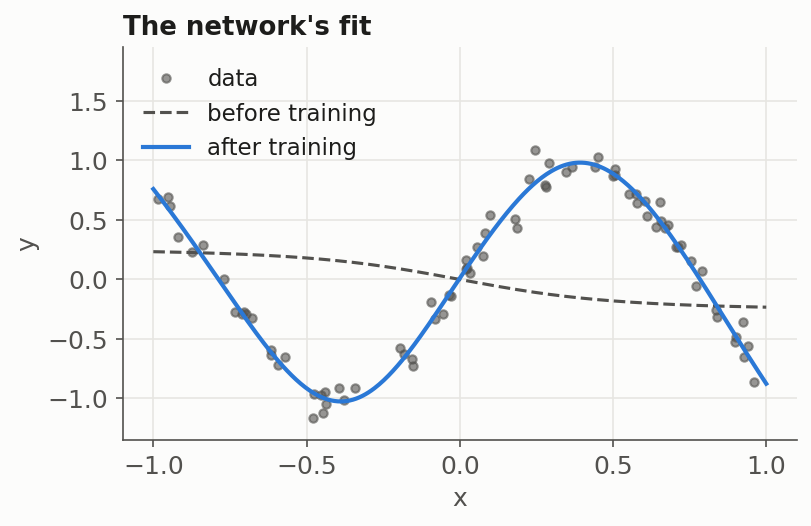

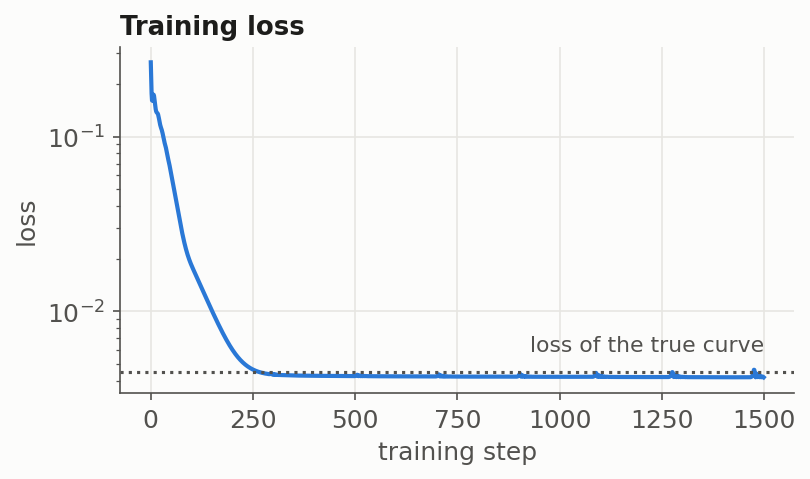

In [8]:
x_plot = np.linspace(-1, 1, 400)[None, :]
fig, ax = plt.subplots(figsize=(5.8, 3.4))
ax.plot(x_data, y_data, "o", color=INK2, ms=4, alpha=0.6, label="data")
ax.plot(x_plot[0], forward(params0, x_plot)[-1][0], color=INK2, ls="--", lw=1.5, label="before training")
ax.plot(x_plot[0], forward(params_trained, x_plot)[-1][0], color=BLUE, label="after training")
ax.set(xlabel="x", ylabel="y", title="The network's fit")
ax.set_ylim(-1.35, 1.95)
ax.legend(loc="upper left")

fig, ax = plt.subplots(figsize=(5.8, 3.0))
ax.semilogy(history, color=BLUE)
loss_true = 0.5 * np.mean((np.sin(4 * x_data) - y_data)**2)    # loss of the true curve on this data
ax.axhline(loss_true, color=INK2, ls=":", lw=1.5)
ax.text(len(history), loss_true * 1.25, "loss of the true curve", color=INK2, fontsize=10.5, ha="right", va="bottom")
ax.set(xlabel="training step", ylabel="loss", title="Training loss")

The dotted line is the loss that the true curve $\sin(4x)$ itself gets on this data, i.e. the loss due purely to the noise. The trained network ends up just below it, so it's fitting a tiny bit of the noise, but for the most part it has captured the curve itself.

## 4. Recap

- A feed-forward network is a loop that updates a vector of activations layer by layer, where each layer's weights and biases enter at that layer.
- Training needs the gradient of **one scalar loss** with respect to **every parameter**.
- **Backpropagation** gets it in one backward pass. It starts from the gradient of the loss at the output, passes an error signal back with $\delta_k = \sigma'(z_k)\odot(W_k^\top\delta_{k+1})$, and reads each layer's gradients off the signal just after it: $\partial\mathcal{L}/\partial W_k = \delta_{k+1}a_k^\top$.
- The cost is only a small multiple of a forward pass, regardless of the number of parameters, but the price is memory, since the forward pass's activations have to be stored for the backward pass.

**Next, in Part 3.** If you've read Part 1, this list probably sounds familiar: a forward pass that stores the states, a single vector swept backward through transposed matrices, gradients for each step's inputs read off the vector just after them, and memory as the price. In Part 3 we put the two recipes side by side and show that they're really the same algorithm.